**Numerical Comparison of KKL Observer Learning Methods**
    
This notebook provides a framework to train and numerically compare four different deep learning-based methods for designing Kazantzis-Kravaris-Luenberger (KKL) observers for autonomous nonlinear systems.
1. **Niazi et al. (2025):** Sequential learning, PINN (SPINN)
2. **Buisson-Fenet et al (2023)** Unsupervised Autoencoder (AE), observer gain tuning.
3. **Miao & Gatsis (2023):** Neural ODE (NODE), learns observer eigenvalues.
3. **Peralez & Nadri (2024):** Deep model-free (DMF), asymptotic version

**Benchmark System:**
1. Reverse Duffing Oscillator
2. Van der Pol Oscillator
3. Rossler attractor
4. Lorenz attractor

**Evaluation Criteria:**
-   **Generalization:** RMSE & SMAPE on unseen data
-   **Computational Cost:** Training time

# Set device

In [1]:
import torch
import torch.nn as nn
from torch import device
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

from tqdm.notebook import tqdm 
from IPython.display import display, clear_output

device = torch.device('cpu')

# System Definitions

First, we define the dynamics and output functions for our continuous-time benchmark systems. We also include an RK4 step function for the discrete-time methods.

In [2]:
import torch
import numpy as np


# --- Oscillators and chaotic systems ---

# Reverse Duffing (Nonlinear Oscillator)
# Used to study bistability and resonance phenomena in mechanical engineering. 
# Duffing models are used to design micro-electromechanical systems (MEMS), vibration isolators, 
# and mechanical energy harvesters that exploit nonlinear resonance to generate power from ambient vibrations.
class ReverseDuffing:
    def __init__(self):
        self.n_x = 2
        self.n_y = 1
        self.name = "ReverseDuffing"
        self.x0_space_bounds = [(-1.0, 1.0), (-1.0, 1.0)] 
        self.x_space_bounds = [(-2.0, 2.0), (-2.0, 2.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2**3
        dx2_dt = -x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Van der Pol Oscillator
# Used in biology to model autonomous rhythms like the spiking of neurons, 
# the beating of the human heart, and circadian clocks, as well as in acoustic modeling for the vocal cords.
class VanDerPol:
    def __init__(self, mu=3.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "VanDerPol"
        self.mu = mu
        self.x0_space_bounds = [(-3.0, 3.0), (-3.0, 3.0)] 
        self.x_space_bounds = [(-5.0, 5.0), (-8.0, 8.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2
        dx2_dt = self.mu * (1 - x1**2) * x2 - x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1] # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Rössler System
# Purely mathematical benchmark
class Rossler:
    def __init__(self, a=0.2, b=0.2, c=5.7):
        self.n_x = 3
        self.n_y = 1
        self.name = "Rossler"
        self.a, self.b, self.c = a, b, c
        self.x0_space_bounds = [(-5.0, 5.0), (-5.0, 5.0), (0.0, 5.0)]
        self.x_space_bounds = [(-10.0, 10.0), (-10.0, 10.0), (0.0, 20.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = -x2 - x3
        dx2_dt = x1 + self.a * x2
        dx3_dt = self.b + x3 * (x1 - self.c)
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Lorenz System
# Used in weather forecasting, data assimilation limits, in secure communications (chaotic cryptography).
class Lorenz:
    def __init__(self, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
        self.n_x = 3
        self.n_y = 1
        self.name = "Lorenz"
        self.sigma, self.rho, self.beta = sigma, rho, beta
        self.x0_space_bounds = [(-10.0, 10.0), (-20.0, 20.0), (0.0, 30.0)]
        self.x_space_bounds = [(-20.0, 20.0), (-30.0, 30.0), (0.0, 50.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = self.sigma * (x2 - x1)
        dx2_dt = x1 * (self.rho - x3) - x2
        dx3_dt = x1 * x2 - self.beta * x3
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



# Helper Functions & Common Components

Generic MLP class and other functions to create observer matrices.

## MLP modules

In [3]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, activation=nn.ReLU):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            # Check if activation is a class or an instance
            if isinstance(activation, nn.Module): # If it's already an instance
                 layers.append(activation)
            else: # Assume it's a class and instantiate it
                 layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [4]:
import torch.nn as nn

# --- MLP builder for DMF method ---
# We must use the original builder to ensure the state_dict keys match perfectly
def create_mlp(input_dim, output_dim, net_arch, activation_fn=nn.Tanh):
    modules = [nn.Linear(input_dim, net_arch[0]), activation_fn()]
    for idx in range(len(net_arch) - 1):
        modules.append(nn.Linear(net_arch[idx], net_arch[idx + 1]))
        modules.append(activation_fn())
    last_layer_dim = net_arch[-1] if len(net_arch) > 0 else input_dim
    modules.append(nn.Linear(last_layer_dim, output_dim))
    return nn.Sequential(*modules)



## Sample x space

In [5]:
import numpy as np
import torch

# sample_x0 accepts state space bounds directly
def sample_x0(bounds, n_samples):
    samples = []
    # Ensure bounds are in (min, max) format
    if isinstance(bounds, list) and isinstance(bounds[0], tuple):
        for (low, high) in bounds:
            samples.append(np.random.uniform(low, high, n_samples))
    else: # Fallback for simple (min, max) array
        low, high = bounds
        samples.append(np.random.uniform(low, high, (n_samples, len(low))))
        return samples[0]

    return np.stack(samples, axis=-1).squeeze()

# sample_x_points samples uniformly from a hyperrectangle defined by min_vals and max_vals
def sample_x_points(min_vals: torch.Tensor, max_vals: torch.Tensor, n_samples: int) -> torch.Tensor:
    n_dim = min_vals.shape[0]
    # Generate random numbers between 0 and 1
    rand_samples = torch.rand(n_samples, n_dim, device=min_vals.device)
    # Scale to desired range
    return min_vals + rand_samples * (max_vals - min_vals)

## Create observer matrices

In [6]:
import numpy as np
import torch

def create_observer_matrices(n_z, n_y, system_name, strategy='diagonal', base_eig=-1.5, device='cpu'):
    """
    Creates a stable A matrix and a B matrix such that (A,B) is controllable.
    For chaotic systems like Lorenz, 'random_stable' enforces a strict eigenvalue 
    spectrum [-3.0, -1.5] to balance injectivity and floating-point precision.
    """
    if strategy == 'random_stable':
        print(f"Using densely coupled A (strict eigenvalues) and random B for {system_name}.")
        
        # 1. Sample eigenvalues strictly in the Goldilocks Zone (-3.0 to -1.5)
        # We use numpy for the QR decomposition as it is mathematically robust
        min_eig = -3.0
        max_eig = -1.5
        eigenvalues = np.random.uniform(min_eig, max_eig, size=n_z)
        D = np.diag(eigenvalues)
        
        # 2. Create a random orthogonal transformation matrix (Q)
        # This creates a dense, highly coupled A matrix without altering the eigenvalues
        H = np.random.randn(n_z, n_z)
        Q, R = np.linalg.qr(H)
        
        # 3. Calculate A = Q * D * Q^T
        A_np = Q @ D @ Q.T
        
        # 4. Generate a random dense B matrix (better for multi-dimensional outputs than ones)
        B_np = np.random.randn(n_z, n_y)
        
        # Cast to PyTorch tensors and push to the correct device
        A = torch.tensor(A_np, dtype=torch.float32, device=device)
        B = torch.tensor(B_np, dtype=torch.float32, device=device)

    elif strategy == 'diagonal':
         print(f"Using diagonal A and ones B for system {system_name}.")
         # Maintain legacy diagonal support if needed
         eigs = torch.linspace(base_eig, base_eig * 3, n_z)
         A = torch.diag(eigs).to(device)
         B = torch.ones((n_z, n_y)).to(device)

    else:
        print(f"Unknown matrix strategy '{strategy}'. Defaulting to diagonal A.")
        eigs = torch.linspace(base_eig, base_eig * 4, n_z)
        A = torch.diag(eigs).to(device)
        B = torch.ones((n_z, n_y)).to(device)

    return A, B

## Data normalization

In [7]:
import numpy

# Data standardization / normalization

def scale_minmax(data, data_min, data_max):
    """Applies Min-Max scaling to [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8 # Avoid division by zero
    return 2.0 * (data - data_min) / data_range - 1.0

def unscale_minmax(scaled_data, data_min, data_max):
    """Applies inverse Min-Max scaling from [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8
    return (scaled_data + 1.0) / 2.0 * data_range + data_min

## Observer class

In [8]:
import torch
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

class Observer:
    def __init__(self, system, A_obs, B_obs, net, t0, tf, N, init_z_zero, scaling_params):
        """
        KKL Observer class

        Args:
            system: The system object (must have f, h, n_x, n_y).
            A_obs: The observer matrix A (torch tensor or numpy array) for system dynamics.
            B_obs: The observer matrix B (torch tensor or numpy array) for system dynamics.
            net: The neural network for the inverse transformation (T_inv_net).
                 (Assumes t_inv_net maps z_scaled -> x_scaled)
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.system = system
        self.A_obs = A_obs.clone().detach().to(device) if isinstance(A_obs, torch.Tensor) else torch.tensor(A_obs, dtype=torch.float32).to(device)
        self.B_obs = B_obs.clone().detach().to(device) if isinstance(B_obs, torch.Tensor) else torch.tensor(B_obs, dtype=torch.float32).to(device)
        self.net = net.to(device) # The inverse map (T_inv_net)

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        self._initial_z_unscaled = torch.zeros(self.A_obs.shape[0], dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.x_min = scaling_params['x_min'].to(device)
        self.x_max = scaling_params['x_max'].to(device)
        self.z_min = scaling_params['z_min'].to(device)
        self.z_max = scaling_params['z_max'].to(device)
        self.y_min = scaling_params['y_min'].to(device)
        self.y_max = scaling_params['y_max'].to(device)

    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics in UNSCALED space) and estimates x (unscaled).
        """
        n_z = self.A_obs.shape[0]
        n_y = self.system.n_y
        n_x = self.system.n_x

        # Initial condition for z observer
        z0_observer_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device) if self.init_z_zero else self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")

        # Create an interpolator for the y_data
        y_data_np = y_data_torch.cpu().numpy()
        t_eval_np = t_eval_torch.cpu().numpy()

        # Use scipy.interpolate.interp1d for robust interpolation
        if n_y == 1:
            y_data_np_interp = y_data_np.squeeze(-1)
        else:
            y_data_np_interp = y_data_np

        y_interp_func_unscaled = interp1d(
            t_eval_np,
            y_data_np_interp,
            axis=0,
            kind='cubic', # linear/cubic
            bounds_error=False,
            fill_value="extrapolate"
        )

        # --- OPTIMIZATION: Pure NumPy Z-Dynamics ---
        # Move matrices to CPU NumPy once to avoid dispatch latency inside the solver loop
        A_np = self.A_obs.cpu().numpy()
        B_np = self.B_obs.cpu().numpy()
        z0_np = z0_observer_unscaled.cpu().numpy()

        def observer_z_dynamics_np(t, z):
            # Pure NumPy math, zero PyTorch overhead
            y_t = y_interp_func_unscaled(t)
            return A_np @ z + B_np @ np.atleast_1d(y_t)

        # Solve using the stiff-aware LSODA algorithm
        sol_z = solve_ivp(
            observer_z_dynamics_np,
            [t_eval_np[0], t_eval_np[-1]],
            z0_np,
            t_eval=t_eval_np,
            method='LSODA'
        )

        # Move the ENTIRE finished trajectory back to the device in one shot
        z_traj_torch_unscaled = torch.tensor(sol_z.y.T, dtype=torch.float32).to(device)


        # --- Network Gating (Batched Evaluation) ---
        # 1. Scale the entire Z trajectory
        z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

        # 2. Estimate scaled X in one massive parallel shot
        with torch.no_grad():
            x_hat_traj_torch_scaled = self.net(z_traj_torch_scaled)

        # 3. Unscale the estimated x trajectory
        x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)

        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled
    


## Simulate and plot function

In [9]:
import torch
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# --- Plotting Function ---

def simulate_and_plot(kkl_observer, x0_test_torch, title="KKL Observer Estimation"):
    """
    Simulates the true system and the KKL observer and plots the results.

    Args:
        kkl_observer: An instance of the Observer class
        x0_test_torch: Initial condition for the true system simulation (torch tensor, shape (n_x,)).
        title: Title for the plot.
    """
    system = kkl_observer.system
    t_eval_torch = kkl_observer.t_eval_torch # Use the time points from the observer
    t_eval_np = t_eval_torch.cpu().numpy()

    # 1. Simulate the true system
    t_span = [kkl_observer.t0, kkl_observer.tf]
    x0_test_np = x0_test_torch.cpu().numpy().flatten()

    # sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='RK45')
    sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='LSODA')

    t_eval_true_np = sol.t
    x_true_np = sol.y.T # Shape (N+1, n_x)
    y_true_np = system.h(x_true_np) # Shape (N+1, n_y)


    # 2. Simulate the KKL observer
    # kkl_observer.simulate expects t_eval_torch and unscaled y_data_torch
    y_true_torch = torch.tensor(y_true_np, dtype=torch.float32).to(device)

    # simulate() returns (z_traj_torch_unscaled, x_hat_traj_torch_unscaled)
    z_hat_traj_unscaled, x_hat_traj_unscaled = kkl_observer.simulate(t_eval_torch, y_true_torch)

    # Convert estimated x trajectory to numpy for plotting
    x_hat_np_unscaled = x_hat_traj_unscaled.cpu().detach().numpy()


    # 3. Plot the results
    plt.figure(figsize=(12, 2 * system.n_x))
    for i in range(system.n_x):
        x_true_component = x_true_np[:, i]
        x_hat_component = x_hat_np_unscaled[:, i]

        plt.subplot(system.n_x, 1, i + 1)
        plt.plot(t_eval_true_np, x_true_component, 'k-', label=f'True x{i+1}')
        plt.plot(t_eval_true_np, x_hat_component, 'm--', label=f'Estimated x{i+1}')
        plt.ylabel(f'x{i+1}')
        plt.grid(True)
        plt.legend()

    plt.xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Comparisons on 100 trials

## Compute metrics (RMSE, SMAPE)

In [11]:
def compute_metrics(X_true, X_hat, transient_cutoff):
    """
    Strips transients and computes RMSE and SMAPE for an entire batch of trajectories.
    Inputs shape: (n_samples, n_steps, n_x)
    """
    X_t = X_true[:, transient_cutoff:, :]
    X_h = X_hat[:, transient_cutoff:, :]
    
    # Root Mean Square Error (RMSE) per trajectory
    rmse = torch.sqrt(torch.mean((X_t - X_h)**2, dim=(1, 2))).numpy()
    
    # Symmetric Mean Absolute Percentage Error (SMAPE) per trajectory
    smape = 100 * torch.mean(2 * torch.abs(X_t - X_h) / (torch.abs(X_t) + torch.abs(X_h) + 1e-8), dim=(1, 2)).numpy()
    
    return rmse, smape

## Simulate z parallel

In [12]:
def simulate_z_parallel(Y_traj, dt, A_c, B_c):
    """Vectorized RK4 solver to simulate 100 observer trajectories simultaneously"""
    n_samples, n_steps, _ = Y_traj.shape
    n_z = A_c.shape[0]
    
    Z_curr = torch.zeros(n_samples, n_z, device=device)
    Z_traj = [Z_curr]
    
    A_t = A_c.to(device)
    B_t = B_c.to(device)
    
    def z_dot(z, y):
        return torch.matmul(z, A_t.T) + torch.matmul(y, B_t.T)
        
    for k in range(n_steps - 1):
        y_curr = Y_traj[:, k, :]
        y_next = Y_traj[:, k+1, :]
        y_mid = (y_curr + y_next) / 2.0 # Approximation for RK4 midpoints
        
        k1 = z_dot(Z_curr, y_curr)
        k2 = z_dot(Z_curr + 0.5 * dt * k1, y_mid)
        k3 = z_dot(Z_curr + 0.5 * dt * k2, y_mid)
        k4 = z_dot(Z_curr + dt * k3, y_next)
        
        Z_curr = Z_curr + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        Z_traj.append(Z_curr)
        
    return torch.stack(Z_traj, dim=1)

## Reverse Duffing

--- Generating 100 OOD Ground Truth Trajectories ---


Solving Ground Truth ODEs:   0%|          | 0/100 [00:00<?, ?it/s]


--- Running Parallel Inference ---
Loading and processing SPINN...
Using diagonal A and ones B for system ReverseDuffing.
Loading and processing AE...
Loading and processing DMF...
Loading and processing NODE...

--- Generating Comparison Plots ---


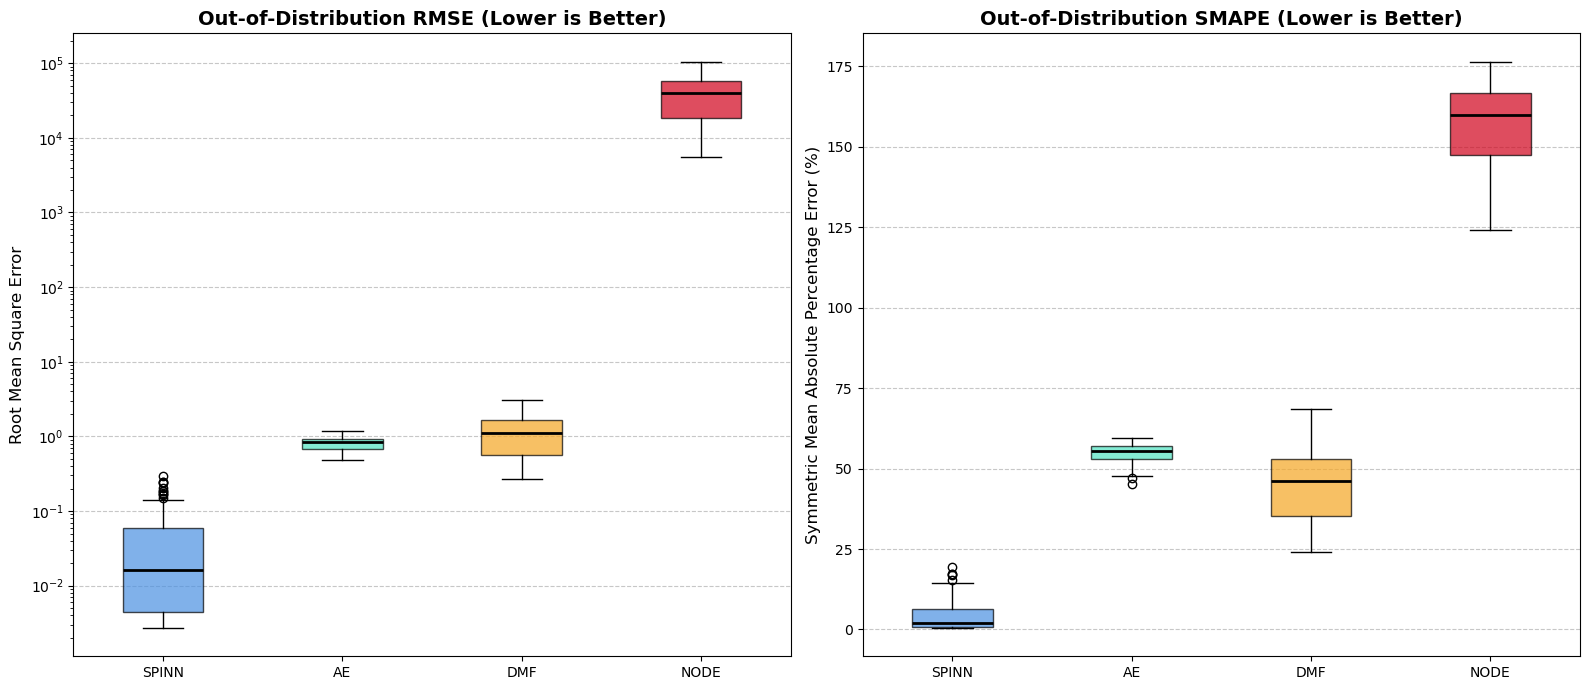


--- Median Results ---
SPINN | Median RMSE: 1.6367e-02 | Median SMAPE: 1.96%
AE    | Median RMSE: 8.3379e-01 | Median SMAPE: 55.39%
DMF   | Median RMSE: 1.1239e+00 | Median SMAPE: 46.20%
NODE  | Median RMSE: 4.0013e+04 | Median SMAPE: 159.82%


In [13]:
# ==============================================================================
# --- 1. System Setup & Out-of-Distribution (OOD) Data Generation ---
# ==============================================================================

system = ReverseDuffing()
t_span = [0, 50]
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
n_steps = len(t_eval)

n_test_samples = 100
print(f"--- Generating {n_test_samples} OOD Ground Truth Trajectories ---")

# Sample strictly OUTSIDE the training boundaries by expanding the box
expansion_factor = 1.5
x0_ood_list = []
bounds = system.x_space_bounds

while len(x0_ood_list) < n_test_samples:
    candidate = [np.random.uniform(b[0] * expansion_factor, b[1] * expansion_factor) for b in bounds]
    inside_original = all(b[0] <= candidate[i] <= b[1] for i, b in enumerate(bounds))
    
    if not inside_original:
        x0_ood_list.append(candidate)

X_true_list, Y_true_list = [], []
for x0 in tqdm(x0_ood_list, desc="Solving Ground Truth ODEs"):
    sol = solve_ivp(system.f, t_span, x0, t_eval=t_eval, method='RK45')
    x_traj = torch.tensor(sol.y.T, dtype=torch.float32).to(device)
    X_true_list.append(x_traj)
    Y_true_list.append(system.h(x_traj))

X_true_torch = torch.stack(X_true_list)
Y_true_torch = torch.stack(Y_true_list)


# ==============================================================================
# --- 2. Parallel Inference Loop Across All Methods ---
# ==============================================================================
methods = ['SPINN', 'AE', 'DMF', 'NODE']
results_rmse = {m: [] for m in methods}
results_smape = {m: [] for m in methods}

# We cut the first 20% of the trajectory to measure actual observer convergence, not starting transients
transient_cutoff = int(0.2 * n_steps) 
n_z = system.n_y * (2 * system.n_x + 1)

print("\n--- Running Parallel Inference ---")

for method in methods:
    print(f"Loading and processing {method}...")
    
    # Check if the method is SPINN to use the 'kkl_models' prefix
    if method == 'SPINN':
        load_path = f"kkl_models_{system.name.lower()}.pth"
    else:
        load_path = f"{method.lower()}_models_{system.name.lower()}.pth"
        
    checkpoint = torch.load(load_path, map_location=device, weights_only=False)
    params = checkpoint['scaling_params']
    x_min, x_max = params['x_min'].to(device), params['x_max'].to(device)
    z_min, z_max = params['z_min'].to(device), params['z_max'].to(device)
    
    # 1. Load Matrices
    if method == 'SPINN':
        # SPINN uses hardcoded matrices
        A_c, B_c = create_observer_matrices(n_z, system.n_y, system.name, strategy='diagonal')
    else:
        # Others learn the continuous matrices (DMF was converted during save)
        A_c = checkpoint['A_obs_learned'].to(device)
        B_c = checkpoint['B_obs_learned'].to(device)

    # 2. Simulate Z Dynamics Vectorized
    Z_traj = simulate_z_parallel(Y_true_torch, dt, A_c, B_c)
    
    # Scale Z according to the method's specific bounds
    Z_input = scale_minmax(Z_traj, z_min, z_max)
    
    # 3. Load Decoder and Predict X
    hidden_dims = checkpoint['hidden_dims']
    activation = checkpoint.get('activation', checkpoint.get('activation2', nn.SiLU))
    if isinstance(activation, type): activation = activation()
    
    with torch.no_grad():
        if method == 'DMF':
            decoder = create_mlp(A_c.shape[0], system.n_x, hidden_dims, activation_fn=type(activation)).to(device)
            decoder.load_state_dict(checkpoint['decoder_state_dict'])
        else:
            decoder = MLP(A_c.shape[0], system.n_x, hidden_dims, activation=activation).to(device)
            state_dict_key = 't_inv_net_state_dict' if method in ['SPINN', 'AE'] else 'decoder_state_dict'
            decoder.load_state_dict(checkpoint[state_dict_key])
            
        decoder.eval()
        X_hat_scaled = decoder(Z_input)
    
    # 4. Unscale and Compute Metrics
    X_hat = unscale_minmax(X_hat_scaled, x_min, x_max)
    
    rmse, smape = compute_metrics(X_true_torch, X_hat, transient_cutoff)
    results_rmse[method] = rmse
    results_smape[method] = smape

results_rmse_duffing = results_rmse.copy()
results_smape_duffing = results_smape.copy()

# ==============================================================================
# --- 3. Plotting the Box Plot Comparisons ---
# ==============================================================================
print("\n--- Generating Comparison Plots ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colors for visual distinction
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

# Plot 1: RMSE
bplot1 = ax1.boxplot([results_rmse[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax1.set_title("Out-of-Distribution RMSE (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Root Mean Square Error", fontsize=12)
ax1.set_yscale('log') # Log scale because bad generalizers will explode
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: SMAPE
bplot2 = ax2.boxplot([results_smape[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax2.set_title("Out-of-Distribution SMAPE (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Symmetric Mean Absolute Percentage Error (%)", fontsize=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Apply colors
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bplot['medians']:
        median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# Print Medians to Console for Paper Tables
print("\n--- Median Results ---")
for m in methods:
    print(f"{m:5s} | Median RMSE: {np.median(results_rmse[m]):.4e} | Median SMAPE: {np.median(results_smape[m]):.2f}%")

## VdP

--- Generating 100 OOD Ground Truth Trajectories ---


Solving Ground Truth ODEs:   0%|          | 0/100 [00:00<?, ?it/s]


--- Running Parallel Inference ---
Loading and processing SPINN...
Using diagonal A and ones B for system VanDerPol.
Loading and processing AE...
Loading and processing DMF...
Loading and processing NODE...

--- Generating Comparison Plots ---


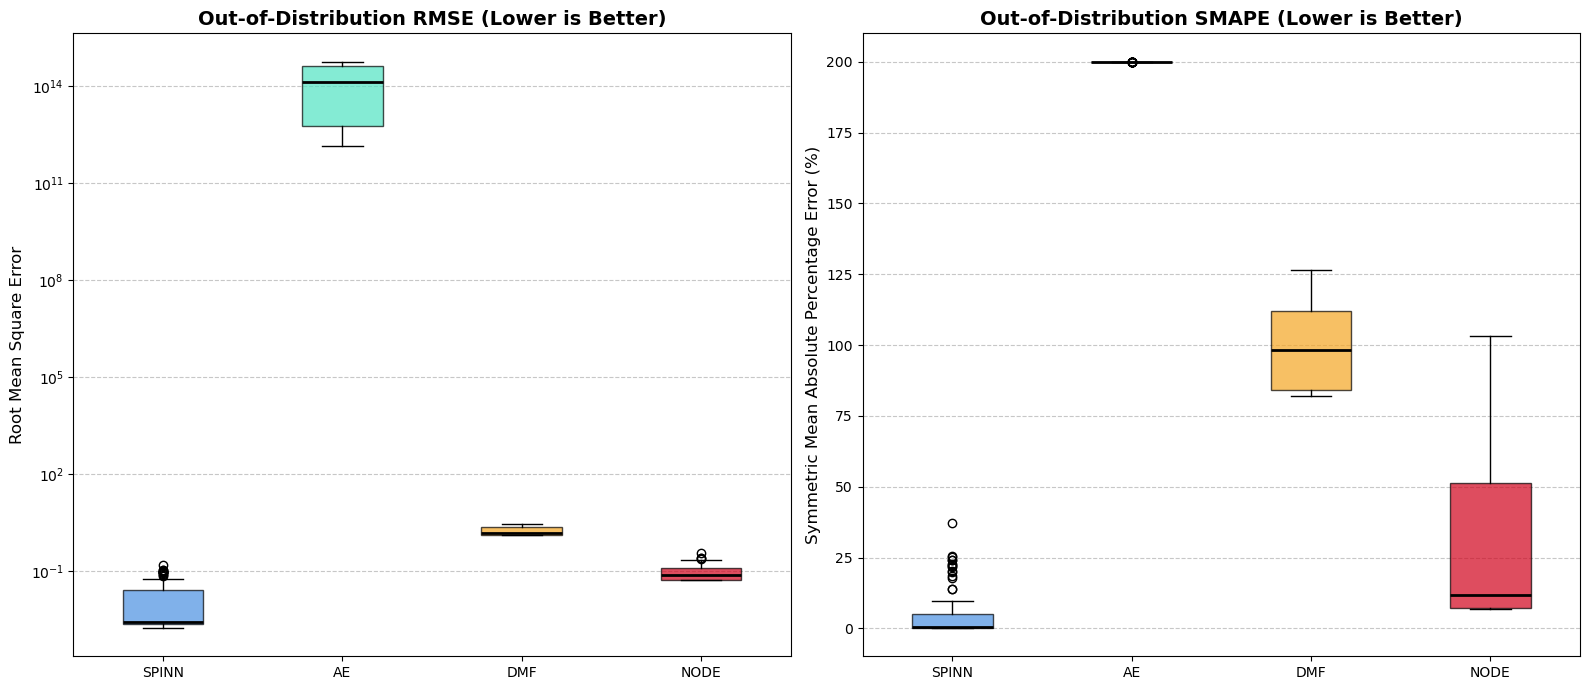


--- Median Results ---
SPINN | Median RMSE: 2.5656e-03 | Median SMAPE: 0.35%
AE    | Median RMSE: 1.3572e+14 | Median SMAPE: 200.00%
DMF   | Median RMSE: 1.5418e+00 | Median SMAPE: 98.23%
NODE  | Median RMSE: 7.5306e-02 | Median SMAPE: 11.91%


In [14]:
# ==============================================================================
# --- 1. System Setup & Out-of-Distribution (OOD) Data Generation ---
# ==============================================================================

system = VanDerPol()
t_span = [0, 50]
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
n_steps = len(t_eval)

n_test_samples = 100
print(f"--- Generating {n_test_samples} OOD Ground Truth Trajectories ---")

# Sample strictly OUTSIDE the training boundaries by expanding the box
expansion_factor = 1.5
x0_ood_list = []
bounds = system.x_space_bounds

while len(x0_ood_list) < n_test_samples:
    candidate = [np.random.uniform(b[0] * expansion_factor, b[1] * expansion_factor) for b in bounds]
    inside_original = all(b[0] <= candidate[i] <= b[1] for i, b in enumerate(bounds))
    
    if not inside_original:
        x0_ood_list.append(candidate)

X_true_list, Y_true_list = [], []
for x0 in tqdm(x0_ood_list, desc="Solving Ground Truth ODEs"):
    sol = solve_ivp(system.f, t_span, x0, t_eval=t_eval, method='RK45')
    x_traj = torch.tensor(sol.y.T, dtype=torch.float32).to(device)
    X_true_list.append(x_traj)
    Y_true_list.append(system.h(x_traj))

X_true_torch = torch.stack(X_true_list)
Y_true_torch = torch.stack(Y_true_list)


# ==============================================================================
# --- 2. Parallel Inference Loop Across All Methods ---
# ==============================================================================
methods = ['SPINN', 'AE', 'DMF', 'NODE']
results_rmse = {m: [] for m in methods}
results_smape = {m: [] for m in methods}

# We cut the first 20% of the trajectory to measure actual observer convergence, not starting transients
transient_cutoff = int(0.2 * n_steps) 
n_z = system.n_y * (2 * system.n_x + 1)

print("\n--- Running Parallel Inference ---")

for method in methods:
    print(f"Loading and processing {method}...")
    
    # Check if the method is SPINN to use the 'kkl_models' prefix
    if method == 'SPINN':
        load_path = f"kkl_models_{system.name.lower()}.pth"
    else:
        load_path = f"{method.lower()}_models_{system.name.lower()}.pth"
        
    checkpoint = torch.load(load_path, map_location=device, weights_only=False)
    params = checkpoint['scaling_params']
    x_min, x_max = params['x_min'].to(device), params['x_max'].to(device)
    z_min, z_max = params['z_min'].to(device), params['z_max'].to(device)
    
    # 1. Load Matrices
    if method == 'SPINN':
        # SPINN uses hardcoded matrices
        A_c, B_c = create_observer_matrices(n_z, system.n_y, system.name, strategy='diagonal')
    else:
        # Others learn the continuous matrices (DMF was converted during save)
        A_c = checkpoint['A_obs_learned'].to(device)
        B_c = checkpoint['B_obs_learned'].to(device)

    # 2. Simulate Z Dynamics Vectorized
    Z_traj = simulate_z_parallel(Y_true_torch, dt, A_c, B_c)
    
    # Scale Z according to the method's specific bounds
    Z_input = scale_minmax(Z_traj, z_min, z_max)
    
    # 3. Load Decoder and Predict X
    hidden_dims = checkpoint['hidden_dims']
    activation = checkpoint.get('activation', checkpoint.get('activation2', nn.SiLU))
    if isinstance(activation, type): activation = activation()
    
    with torch.no_grad():
        if method == 'DMF':
            decoder = create_mlp(A_c.shape[0], system.n_x, hidden_dims, activation_fn=type(activation)).to(device)
            decoder.load_state_dict(checkpoint['decoder_state_dict'])
        else:
            decoder = MLP(A_c.shape[0], system.n_x, hidden_dims, activation=activation).to(device)
            state_dict_key = 't_inv_net_state_dict' if method in ['SPINN', 'AE'] else 'decoder_state_dict'
            decoder.load_state_dict(checkpoint[state_dict_key])
            
        decoder.eval()
        X_hat_scaled = decoder(Z_input)
    
    # 4. Unscale and Compute Metrics
    X_hat = unscale_minmax(X_hat_scaled, x_min, x_max)
    
    rmse, smape = compute_metrics(X_true_torch, X_hat, transient_cutoff)
    results_rmse[method] = rmse
    results_smape[method] = smape

results_rmse_vdp = results_rmse.copy()
results_smape_vdp = results_smape.copy()

# ==============================================================================
# --- 3. Plotting the Box Plot Comparisons ---
# ==============================================================================
print("\n--- Generating Comparison Plots ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colors for visual distinction
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

# Plot 1: RMSE
bplot1 = ax1.boxplot([results_rmse[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax1.set_title("Out-of-Distribution RMSE (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Root Mean Square Error", fontsize=12)
ax1.set_yscale('log') # Log scale because bad generalizers will explode
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: SMAPE
bplot2 = ax2.boxplot([results_smape[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax2.set_title("Out-of-Distribution SMAPE (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Symmetric Mean Absolute Percentage Error (%)", fontsize=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Apply colors
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bplot['medians']:
        median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# Print Medians to Console for Paper Tables
print("\n--- Median Results ---")
for m in methods:
    print(f"{m:5s} | Median RMSE: {np.median(results_rmse[m]):.4e} | Median SMAPE: {np.median(results_smape[m]):.2f}%")

## Rossler

--- Generating 100 OOD Ground Truth Trajectories ---


Solving Ground Truth ODEs:   0%|          | 0/100 [00:00<?, ?it/s]


--- Running Parallel Inference ---
Loading and processing SPINN...
Using diagonal A and ones B for system Rossler.
Loading and processing AE...
Loading and processing DMF...
Loading and processing NODE...

--- Generating Comparison Plots ---


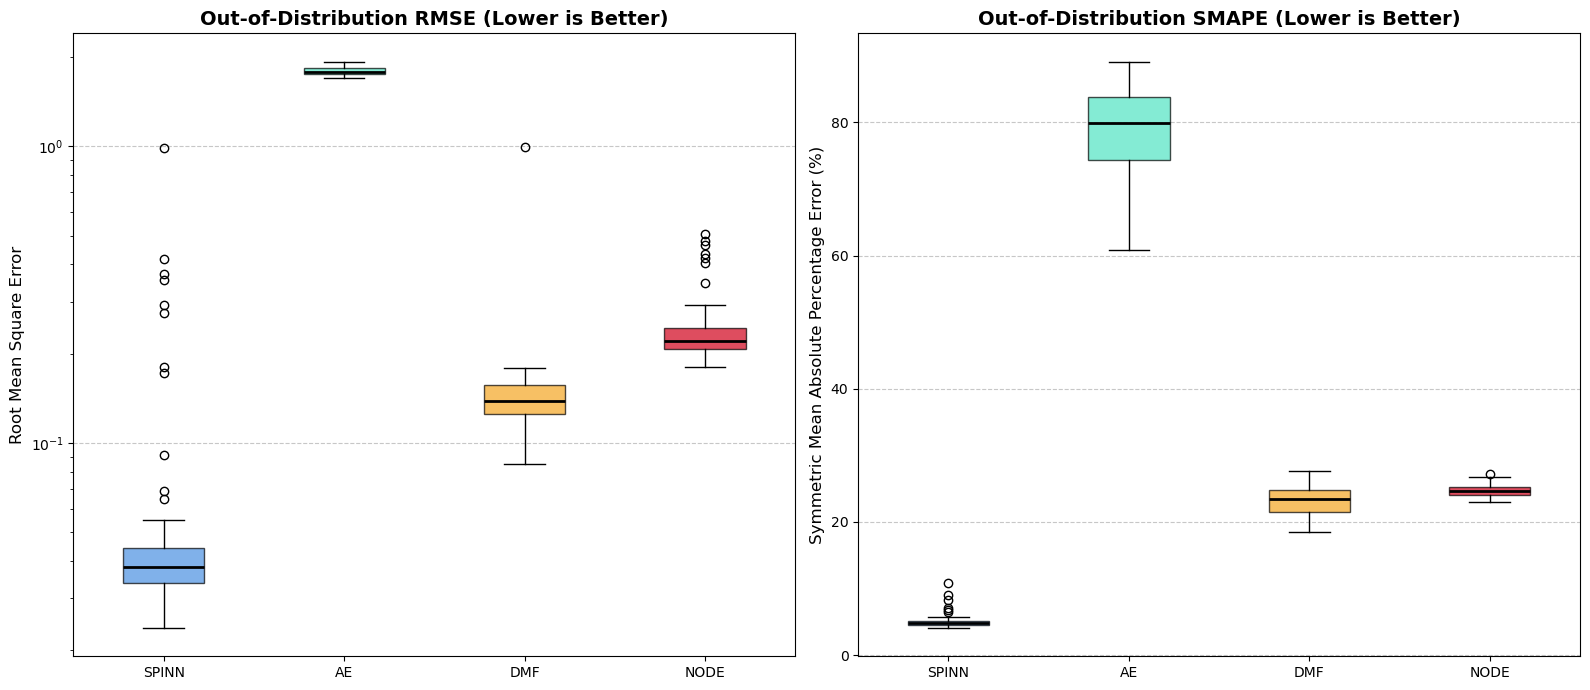


--- Median Results ---
SPINN | Median RMSE: 3.8023e-02 | Median SMAPE: 4.77%
AE    | Median RMSE: 1.7896e+00 | Median SMAPE: 79.94%
DMF   | Median RMSE: 1.3846e-01 | Median SMAPE: 23.48%
NODE  | Median RMSE: 2.2094e-01 | Median SMAPE: 24.72%


In [15]:
# ==============================================================================
# --- 1. System Setup & Out-of-Distribution (OOD) Data Generation ---
# ==============================================================================

system = Rossler()
t_span = [0, 50]
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
n_steps = len(t_eval)

n_test_samples = 100
print(f"--- Generating {n_test_samples} OOD Ground Truth Trajectories ---")

# Sample strictly OUTSIDE the training boundaries by expanding the box
expansion_factor = 1.5
x0_ood_list = []
bounds = system.x_space_bounds

while len(x0_ood_list) < n_test_samples:
    candidate = [np.random.uniform(b[0] * expansion_factor, b[1] * expansion_factor) for b in bounds]
    inside_original = all(b[0] <= candidate[i] <= b[1] for i, b in enumerate(bounds))
    
    if not inside_original:
        x0_ood_list.append(candidate)

X_true_list, Y_true_list = [], []
for x0 in tqdm(x0_ood_list, desc="Solving Ground Truth ODEs"):
    sol = solve_ivp(system.f, t_span, x0, t_eval=t_eval, method='RK45')
    x_traj = torch.tensor(sol.y.T, dtype=torch.float32).to(device)
    X_true_list.append(x_traj)
    Y_true_list.append(system.h(x_traj))

X_true_torch = torch.stack(X_true_list)
Y_true_torch = torch.stack(Y_true_list)


# ==============================================================================
# --- 2. Parallel Inference Loop Across All Methods ---
# ==============================================================================
methods = ['SPINN', 'AE', 'DMF', 'NODE']
results_rmse = {m: [] for m in methods}
results_smape = {m: [] for m in methods}

# We cut the first 20% of the trajectory to measure actual observer convergence, not starting transients
transient_cutoff = int(0.2 * n_steps) 
n_z = system.n_y * (2 * system.n_x + 1)

print("\n--- Running Parallel Inference ---")

for method in methods:
    print(f"Loading and processing {method}...")
    
    # Check if the method is SPINN to use the 'kkl_models' prefix
    if method == 'SPINN':
        load_path = f"kkl_models_{system.name.lower()}.pth"
    else:
        load_path = f"{method.lower()}_models_{system.name.lower()}.pth"
        
    checkpoint = torch.load(load_path, map_location=device, weights_only=False)
    params = checkpoint['scaling_params']
    x_min, x_max = params['x_min'].to(device), params['x_max'].to(device)
    z_min, z_max = params['z_min'].to(device), params['z_max'].to(device)
    
    # 1. Load Matrices
    if method == 'SPINN':
        # SPINN uses hardcoded matrices
        A_c, B_c = create_observer_matrices(n_z, system.n_y, system.name, strategy='diagonal')
    else:
        # Others learn the continuous matrices (DMF was converted during save)
        A_c = checkpoint['A_obs_learned'].to(device)
        B_c = checkpoint['B_obs_learned'].to(device)

    # 2. Simulate Z Dynamics Vectorized
    Z_traj = simulate_z_parallel(Y_true_torch, dt, A_c, B_c)
    
    # Scale Z according to the method's specific bounds
    Z_input = scale_minmax(Z_traj, z_min, z_max)
    
    # 3. Load Decoder and Predict X
    hidden_dims = checkpoint['hidden_dims']
    activation = checkpoint.get('activation', checkpoint.get('activation2', nn.SiLU))
    if isinstance(activation, type): activation = activation()
    
    with torch.no_grad():
        if method == 'DMF':
            decoder = create_mlp(A_c.shape[0], system.n_x, hidden_dims, activation_fn=type(activation)).to(device)
            decoder.load_state_dict(checkpoint['decoder_state_dict'])
        else:
            decoder = MLP(A_c.shape[0], system.n_x, hidden_dims, activation=activation).to(device)
            state_dict_key = 't_inv_net_state_dict' if method in ['SPINN', 'AE'] else 'decoder_state_dict'
            decoder.load_state_dict(checkpoint[state_dict_key])
            
        decoder.eval()
        X_hat_scaled = decoder(Z_input)
    
    # 4. Unscale and Compute Metrics
    X_hat = unscale_minmax(X_hat_scaled, x_min, x_max)
    
    rmse, smape = compute_metrics(X_true_torch, X_hat, transient_cutoff)
    results_rmse[method] = rmse
    results_smape[method] = smape

results_rmse_rossler = results_rmse.copy()
results_smape_rossler = results_smape.copy()

# ==============================================================================
# --- 3. Plotting the Box Plot Comparisons ---
# ==============================================================================
print("\n--- Generating Comparison Plots ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colors for visual distinction
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

# Plot 1: RMSE
bplot1 = ax1.boxplot([results_rmse[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax1.set_title("Out-of-Distribution RMSE (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Root Mean Square Error", fontsize=12)
ax1.set_yscale('log') # Log scale because bad generalizers will explode
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: SMAPE
bplot2 = ax2.boxplot([results_smape[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax2.set_title("Out-of-Distribution SMAPE (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Symmetric Mean Absolute Percentage Error (%)", fontsize=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Apply colors
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bplot['medians']:
        median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# Print Medians to Console for Paper Tables
print("\n--- Median Results ---")
for m in methods:
    print(f"{m:5s} | Median RMSE: {np.median(results_rmse[m]):.4e} | Median SMAPE: {np.median(results_smape[m]):.2f}%")

## Lorenz

--- Generating 100 OOD Ground Truth Trajectories ---


Solving Ground Truth ODEs:   0%|          | 0/100 [00:00<?, ?it/s]


--- Running Parallel Inference ---
Loading and processing SPINN...
Using diagonal A and ones B for system Lorenz.
Loading and processing AE...
Loading and processing DMF...
Loading and processing NODE...

--- Generating Comparison Plots ---


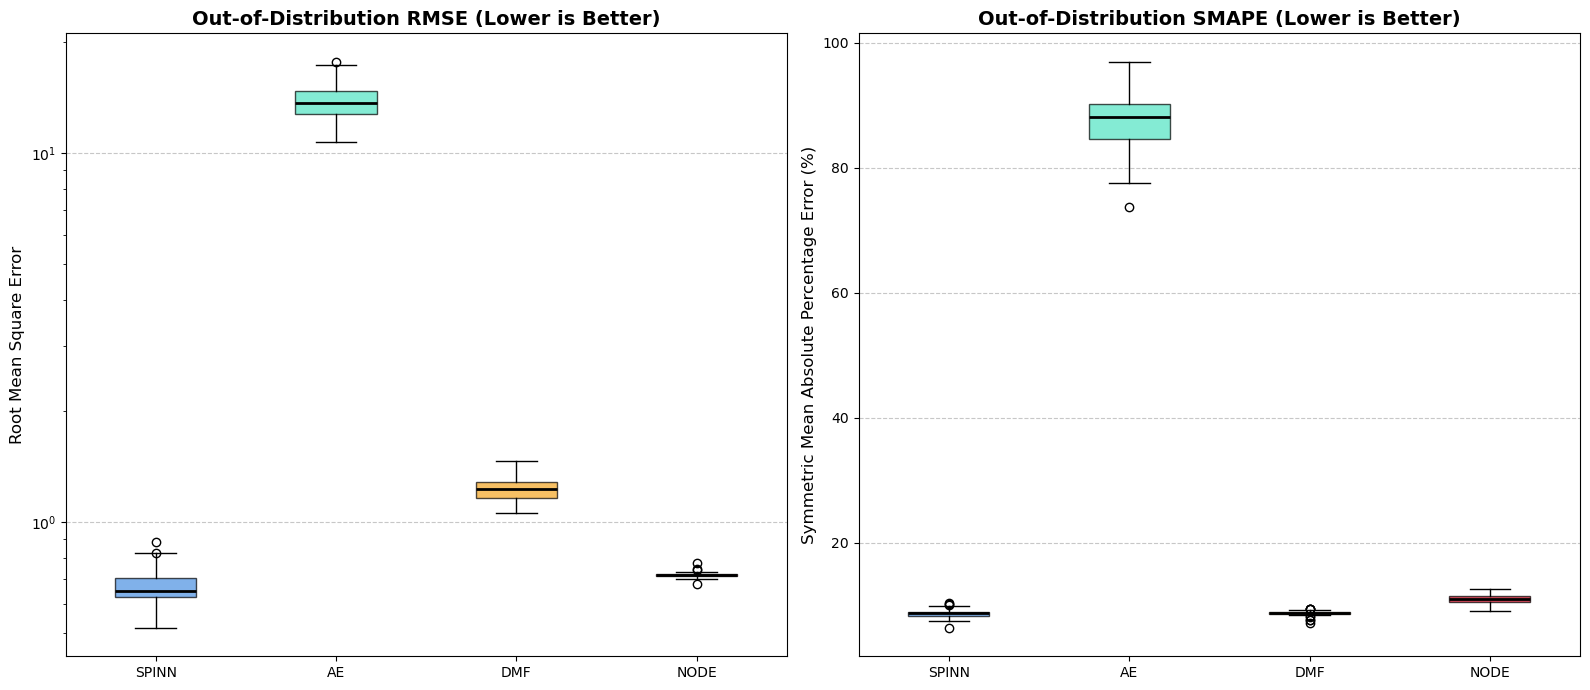


--- Median Results ---
SPINN | Median RMSE: 6.5091e-01 | Median SMAPE: 8.64%
AE    | Median RMSE: 1.3708e+01 | Median SMAPE: 88.09%
DMF   | Median RMSE: 1.2264e+00 | Median SMAPE: 8.76%
NODE  | Median RMSE: 7.1765e-01 | Median SMAPE: 11.01%


In [16]:
# ==============================================================================
# --- 1. System Setup & Out-of-Distribution (OOD) Data Generation ---
# ==============================================================================

system = Lorenz()
t_span = [0, 50]
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
n_steps = len(t_eval)

n_test_samples = 100
print(f"--- Generating {n_test_samples} OOD Ground Truth Trajectories ---")

# Sample strictly OUTSIDE the training boundaries by expanding the box
expansion_factor = 1.5
x0_ood_list = []
bounds = system.x_space_bounds

while len(x0_ood_list) < n_test_samples:
    candidate = [np.random.uniform(b[0] * expansion_factor, b[1] * expansion_factor) for b in bounds]
    inside_original = all(b[0] <= candidate[i] <= b[1] for i, b in enumerate(bounds))
    
    if not inside_original:
        x0_ood_list.append(candidate)

X_true_list, Y_true_list = [], []
for x0 in tqdm(x0_ood_list, desc="Solving Ground Truth ODEs"):
    sol = solve_ivp(system.f, t_span, x0, t_eval=t_eval, method='RK45')
    x_traj = torch.tensor(sol.y.T, dtype=torch.float32).to(device)
    X_true_list.append(x_traj)
    Y_true_list.append(system.h(x_traj))

X_true_torch = torch.stack(X_true_list)
Y_true_torch = torch.stack(Y_true_list)


# ==============================================================================
# --- 2. Parallel Inference Loop Across All Methods ---
# ==============================================================================
methods = ['SPINN', 'AE', 'DMF', 'NODE']
results_rmse = {m: [] for m in methods}
results_smape = {m: [] for m in methods}

# We cut the first 20% of the trajectory to measure actual observer convergence, not starting transients
transient_cutoff = int(0.2 * n_steps) 
n_z = system.n_y * (2 * system.n_x + 1)

print("\n--- Running Parallel Inference ---")

for method in methods:
    print(f"Loading and processing {method}...")
    
    # Check if the method is SPINN to use the 'kkl_models' prefix
    if method == 'SPINN':
        load_path = f"kkl_models_{system.name.lower()}.pth"
    else:
        load_path = f"{method.lower()}_models_{system.name.lower()}.pth"
        
    checkpoint = torch.load(load_path, map_location=device, weights_only=False)
    params = checkpoint['scaling_params']
    x_min, x_max = params['x_min'].to(device), params['x_max'].to(device)
    z_min, z_max = params['z_min'].to(device), params['z_max'].to(device)
    
    # 1. Load Matrices
    if method == 'SPINN':
        # SPINN uses hardcoded matrices
        A_c, B_c = create_observer_matrices(n_z, system.n_y, system.name, strategy='diagonal')
    else:
        # Others learn the continuous matrices (DMF was converted during save)
        A_c = checkpoint['A_obs_learned'].to(device)
        B_c = checkpoint['B_obs_learned'].to(device)

    # 2. Simulate Z Dynamics Vectorized
    Z_traj = simulate_z_parallel(Y_true_torch, dt, A_c, B_c)
    
    # Scale Z according to the method's specific bounds
    Z_input = scale_minmax(Z_traj, z_min, z_max)
    
    # 3. Load Decoder and Predict X
    hidden_dims = checkpoint['hidden_dims']
    activation = checkpoint.get('activation', checkpoint.get('activation2', nn.SiLU))
    if isinstance(activation, type): activation = activation()
    
    with torch.no_grad():
        if method == 'DMF':
            decoder = create_mlp(A_c.shape[0], system.n_x, hidden_dims, activation_fn=type(activation)).to(device)
            decoder.load_state_dict(checkpoint['decoder_state_dict'])
        else:
            decoder = MLP(A_c.shape[0], system.n_x, hidden_dims, activation=activation).to(device)
            state_dict_key = 't_inv_net_state_dict' if method in ['SPINN', 'AE'] else 'decoder_state_dict'
            decoder.load_state_dict(checkpoint[state_dict_key])
            
        decoder.eval()
        X_hat_scaled = decoder(Z_input)
    
    # 4. Unscale and Compute Metrics
    X_hat = unscale_minmax(X_hat_scaled, x_min, x_max)
    
    rmse, smape = compute_metrics(X_true_torch, X_hat, transient_cutoff)
    results_rmse[method] = rmse
    results_smape[method] = smape

results_rmse_lorenz = results_rmse.copy()
results_smape_lorenz = results_smape.copy()

# ==============================================================================
# --- 3. Plotting the Box Plot Comparisons ---
# ==============================================================================
print("\n--- Generating Comparison Plots ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colors for visual distinction
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

# Plot 1: RMSE
bplot1 = ax1.boxplot([results_rmse[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax1.set_title("Out-of-Distribution RMSE (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Root Mean Square Error", fontsize=12)
ax1.set_yscale('log') # Log scale because bad generalizers will explode
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: SMAPE
bplot2 = ax2.boxplot([results_smape[m] for m in methods], 
                     patch_artist=True, tick_labels=methods, showfliers=True)
ax2.set_title("Out-of-Distribution SMAPE (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Symmetric Mean Absolute Percentage Error (%)", fontsize=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Apply colors
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bplot['medians']:
        median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# Print Medians to Console for Paper Tables
print("\n--- Median Results ---")
for m in methods:
    print(f"{m:5s} | Median RMSE: {np.median(results_rmse[m]):.4e} | Median SMAPE: {np.median(results_smape[m]):.2f}%")

## SMAPE plot

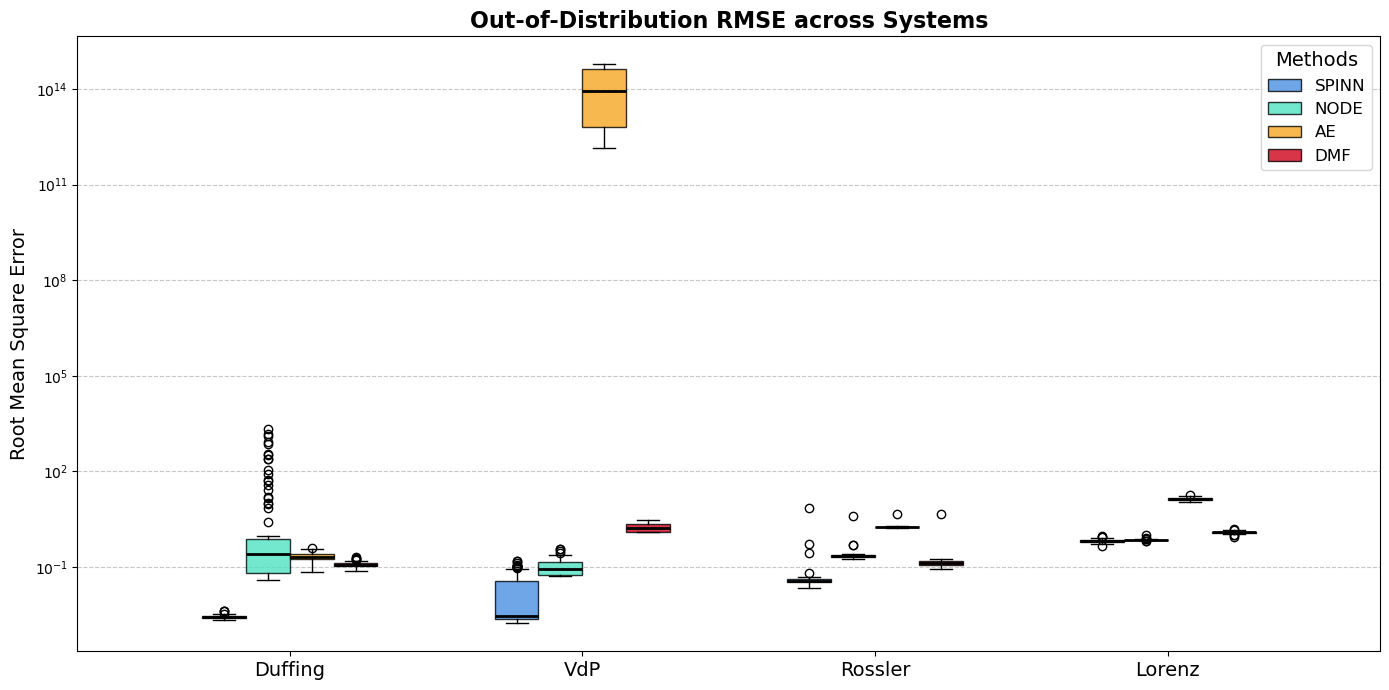

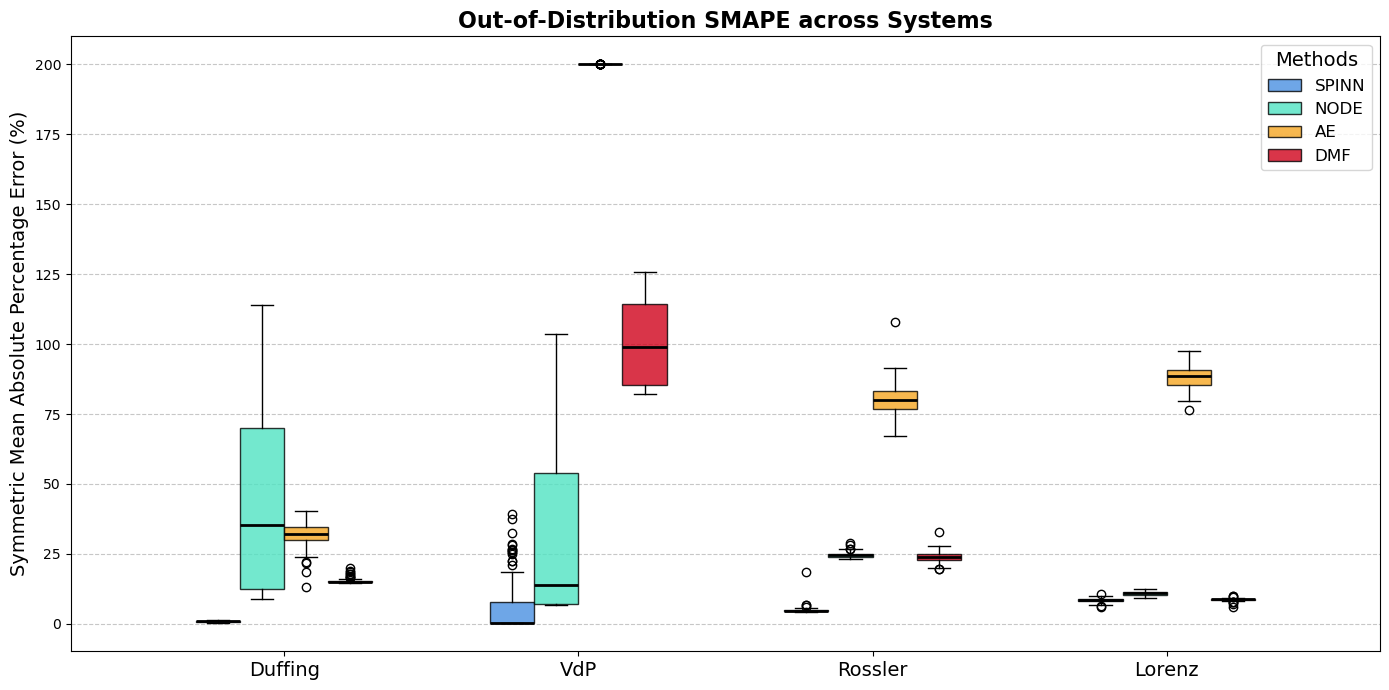

In [152]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. Aggregate your Data 
# (Make sure to assign these variables at the end of each system's section)
# ==============================================================================
all_results_rmse = {
    'Duffing': results_rmse_duffing,  # dict containing {'SPINN': [...], 'AE': [...], etc.}
    'VdP': results_rmse_vdp,
    'Rossler': results_rmse_rossler,
    'Lorenz': results_rmse_lorenz
}

all_results_smape = {
    'Duffing': results_smape_duffing,
    'VdP': results_smape_vdp,
    'Rossler': results_smape_rossler,
    'Lorenz': results_smape_lorenz
}

# ==============================================================================
# 2. Plotting Configuration
# ==============================================================================
systems = ['Duffing', 'VdP', 'Rossler', 'Lorenz']
methods = ['SPINN', 'NODE', 'AE', 'DMF']
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']

# Create two separate figures
fig1, ax1 = plt.subplots(figsize=(14, 7))
fig2, ax2 = plt.subplots(figsize=(14, 7))

# Width of each box and spacing
box_width = 0.15
# X positions for the 4 SYSTEMS on the axis (instead of methods)
x_positions = np.arange(len(systems))

# ==============================================================================
# 3. Generate Grouped Box Plots
# ==============================================================================
for ax, all_results, title, ylabel, use_log in zip(
    [ax1, ax2],
    [all_results_rmse, all_results_smape],
    ["Out-of-Distribution RMSE across Systems", "Out-of-Distribution SMAPE across Systems"],
    ["Root Mean Square Error", "Symmetric Mean Absolute Percentage Error (%)"],
    [True, False]
):
    
    legend_patches = []
    
    # Iterate through each METHOD to plot its boxes across all 4 systems
    for j, method in enumerate(methods):
        # Calculate the offset to group the 4 methods around the system's x-tick
        # Offsets will be: -0.225, -0.075, 0.075, 0.225
        offset = (j - 1.5) * box_width
        
        # Extract data for this specific method across all 4 systems
        data_to_plot = [all_results[system][method] for system in systems]
        
        # Plot the boxplots
        bplot = ax.boxplot(data_to_plot, 
                           positions=x_positions + offset, 
                           widths=box_width,
                           patch_artist=True,
                           showfliers=True)
        
        # Color the boxes for this specific method
        for patch in bplot['boxes']:
            patch.set_facecolor(colors[j])
            patch.set_alpha(0.8)
        for median in bplot['medians']:
            median.set(color='black', linewidth=2)
            
        # Save one patch to use in the legend
        legend_patches.append(bplot['boxes'][0])

    # Formatting the axes
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14)
    
    # Set the x-ticks to represent the systems/examples
    ax.set_xticks(x_positions)
    ax.set_xticklabels(systems, fontsize=14)
    
    # Use a logarithmic scale for RMSE 
    if use_log:
        ax.set_yscale('log')
        
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Add a custom legend for the methods
    ax.legend(legend_patches, methods, loc='upper right', fontsize=12, title="Methods", title_fontsize=14)

fig1.tight_layout()
fig2.tight_layout()

plt.show()

/var/folders/x0/491fxsj52ms_1ssdtl5sm1lc0000gn/T/ipykernel_1919/606496311.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g_rmse = sns.catplot(
/var/folders/x0/491fxsj52ms_1ssdtl5sm1lc0000gn/T/ipykernel_1919/606496311.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g_smape = sns.catplot(


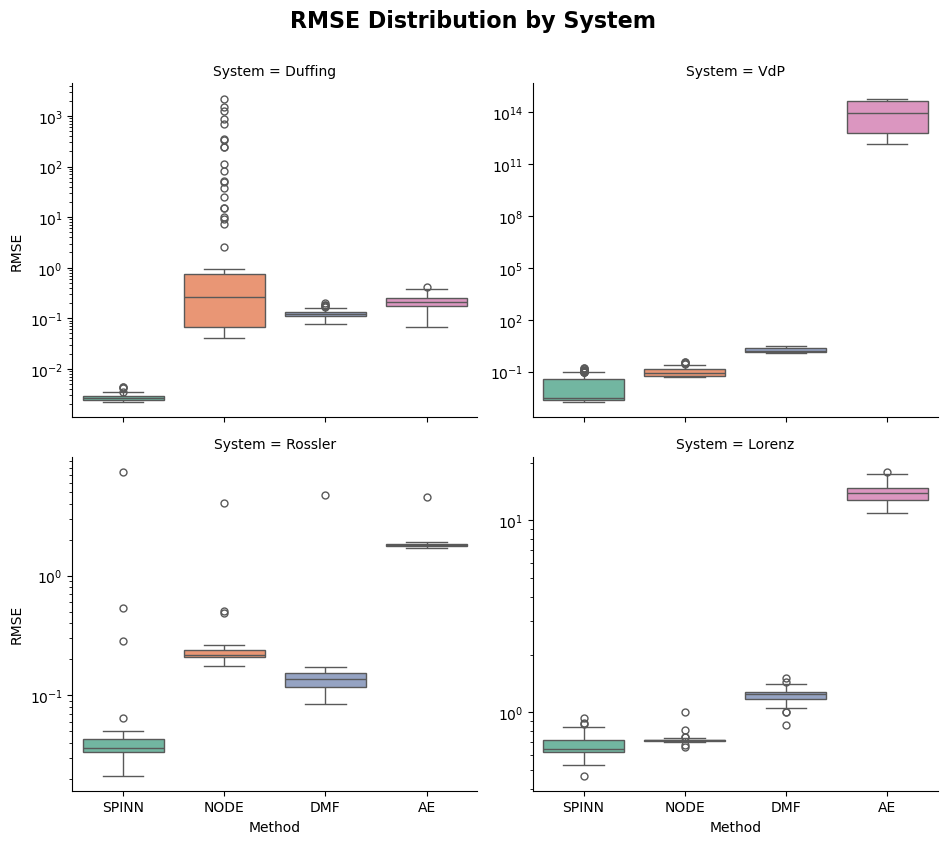

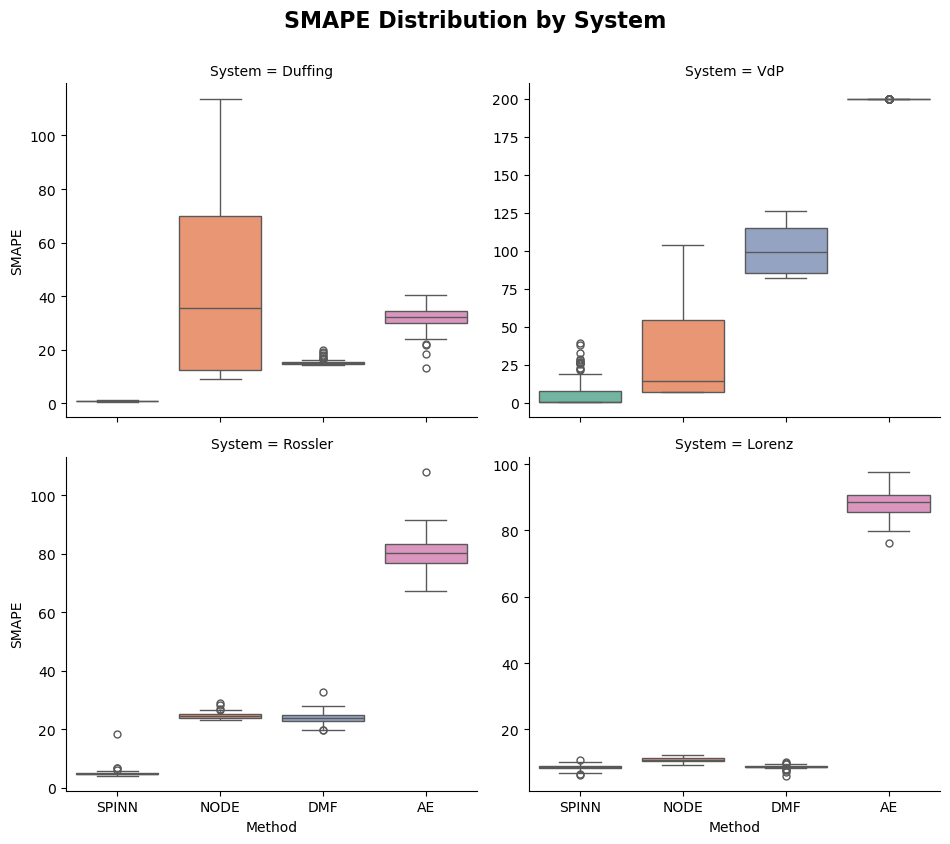

In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

systems = ['Duffing', 'VdP', 'Rossler', 'Lorenz']
methods = ['SPINN', 'NODE', 'DMF', 'AE']

# Convert nested dictionaries into a flat list of records
records = []
for sys in systems:
    for meth in methods:
        # Assuming you assigned these earlier
        rmse_vals = all_results_rmse[sys][meth]
        smape_vals = all_results_smape[sys][meth]
        
        for r, s in zip(rmse_vals, smape_vals):
            records.append({'System': sys, 'Method': meth, 'RMSE': r, 'SMAPE': s})

# Create the master DataFrame
df = pd.DataFrame(records)

# 1. Faceted Boxplot for RMSE
g_rmse = sns.catplot(
    data=df, x='Method', y='RMSE', col='System', col_wrap=2, 
    kind='box', sharey=False, palette='Set2', height=4, aspect=1.2
)
g_rmse.fig.suptitle("RMSE Distribution by System", y=1.05, fontsize=16, fontweight='bold')
# Optional: Set log scale if there are massive outliers
for ax in g_rmse.axes.flat:
    ax.set_yscale('log')

# 2. Faceted Boxplot for SMAPE
g_smape = sns.catplot(
    data=df, x='Method', y='SMAPE', col='System', col_wrap=2, 
    kind='box', sharey=False, palette='Set2', height=4, aspect=1.2
)
g_smape.fig.suptitle("SMAPE Distribution by System", y=1.05, fontsize=16, fontweight='bold')

plt.show()

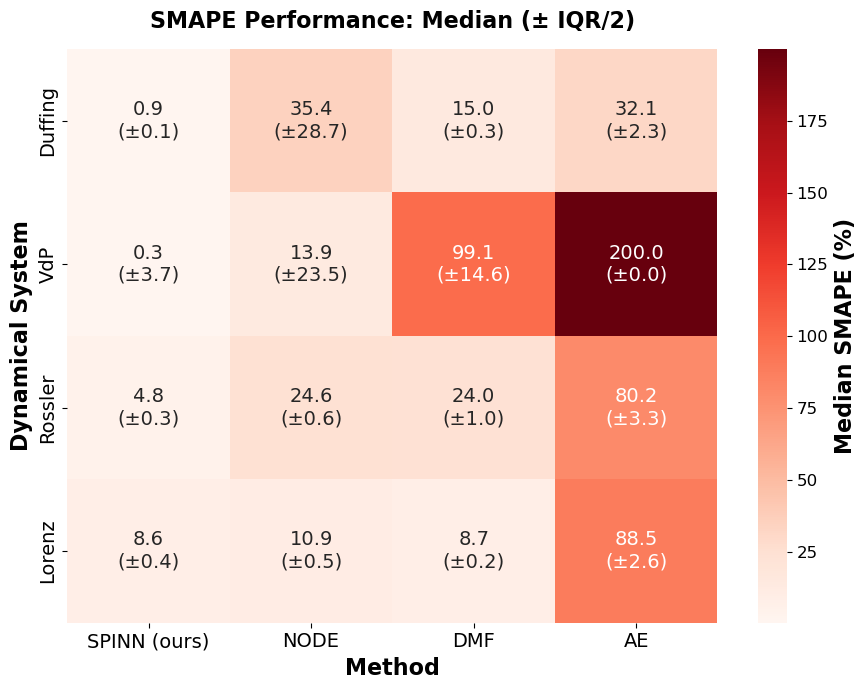

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. Data Modification (Vectorized)
# ==============================================================================
df['Method'] = df['Method'].replace({'SPINN': 'SPINN (ours)'})
methods = ['SPINN (ours)', 'NODE', 'DMF', 'AE']
systems = ['Duffing', 'VdP', 'Rossler', 'Lorenz']

# ==============================================================================
# 2. Compute Robust Statistics (Median and IQR)
# ==============================================================================
# Compute median and IQR simultaneously using optimized Pandas aggregations
agg_df = df.groupby(['System', 'Method'])['SMAPE'].agg(
    median='median',
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index()

# Pivot the data into matrices aligned with your axes
pivot_median = agg_df.pivot(index='System', columns='Method', values='median').reindex(systems)[methods]
pivot_iqr = agg_df.pivot(index='System', columns='Method', values='iqr').reindex(systems)[methods]

# ==============================================================================
# 3. Construct Custom Annotation Matrix
# ==============================================================================
# Create an array of strings formatted as "Median \n (± IQR/2)"
annot_labels = np.empty_like(pivot_median, dtype=object)

for i in range(pivot_median.shape[0]):
    for j in range(pivot_median.shape[1]):
        med_val = pivot_median.iloc[i, j]
        err_val = pivot_iqr.iloc[i, j] / 2.0  # Half IQR for the ± margin
        annot_labels[i, j] = f"{med_val:.1f}\n(±{err_val:.1f})"

# ==============================================================================
# 4. Plotting & High-Resolution Export
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 7))

# Plot the Heatmap
# Note: fmt="" is required because we are passing custom strings instead of floats
heatmap = sns.heatmap(
    pivot_median, 
    annot=annot_labels, 
    fmt="",             
    cmap="Reds", 
    ax=ax,
    annot_kws={"size": 14}, #, "weight": "bold"}, 
    cbar_kws={'label': 'Median SMAPE (%)'}
)

# Modify the Heatmap Colorbar Label Font Size
cbar = heatmap.collections[0].colorbar
cbar.set_label('Median SMAPE (%)', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Modify Title, X-axis, and Y-axis Font Sizes
ax.set_title("SMAPE Performance: Median (± IQR/2)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Method", fontsize=16, fontweight='bold')
ax.set_ylabel("Dynamical System", fontsize=16, fontweight='bold')

# Increase the size of the X and Y tick labels 
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()

# Save the figure as a high-resolution PNG
plt.savefig("SMAPE_Robust_Comparison_Heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

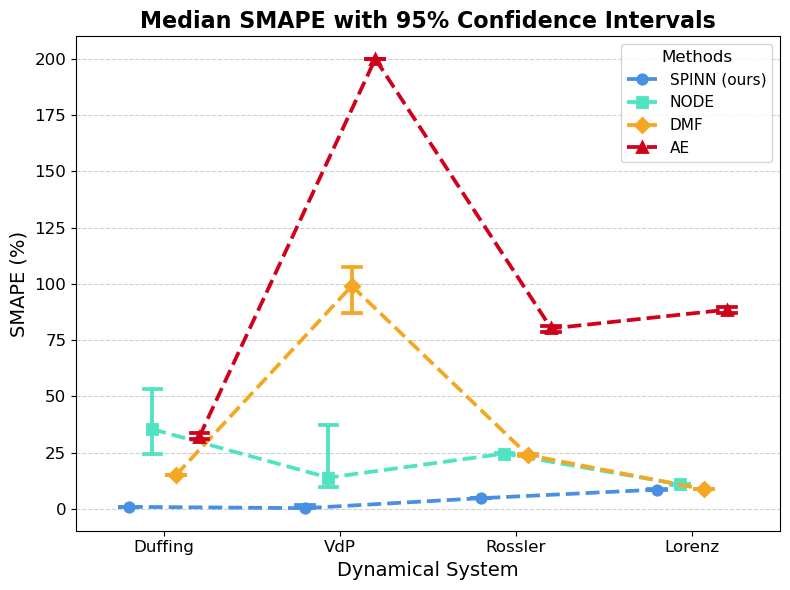

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Create a point plot
# - estimator=np.median ensures the dot represents the median (not the mean)
# - errorbar=('ci', 95) calculates the 95% Confidence Interval
# - dodge=True spreads the methods out side-by-side so the error bars don't overlap
sns.pointplot(
    data=df, 
    x='System', 
    y='SMAPE', 
    hue='Method',
    estimator=np.median,
    errorbar=('ci', 99),  
    capsize=0.1,          # Adds horizontal caps to the error bars
    dodge=0.4,            # Spacing between the points
    markers=['o', 's', 'D', '^'], # Different shapes for each method
    linestyles='--',      # Connects the systems with dashed lines to show trends
    palette=['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']
)

# Formatting
ax.set_title("Median SMAPE with 95% Confidence Intervals", fontsize=16, fontweight='bold')
ax.set_ylabel("SMAPE (%)", fontsize=14)
ax.set_xlabel("Dynamical System", fontsize=14)
ax.tick_params(labelsize=12)

# Improve legend
plt.legend(title="Methods", title_fontsize=12, fontsize=11, loc='upper right')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()